In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:45.549397
2,2020-04-17 05:34:24.422370
3,2020-04-17 05:43:27.773992
4,2020-04-17 05:46:32.275104


## Add hour and day type

In [3]:
commits['hour'] = commits['timestamp'].dt.hour
commits['dayofweek'] = commits['timestamp'].dt.dayofweek
commits['day_type'] = commits['dayofweek'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)

working_hours = commits[commits['day_type'] == 'working_day']['hour'].tolist()
weekend_hours = commits[commits['day_type'] == 'weekend']['hour'].tolist()

print('Working day commits:', len(working_hours))
print('Weekend commits:', len(weekend_hours))

Working day commits: 1059
Weekend commits: 627


## Plot histogram

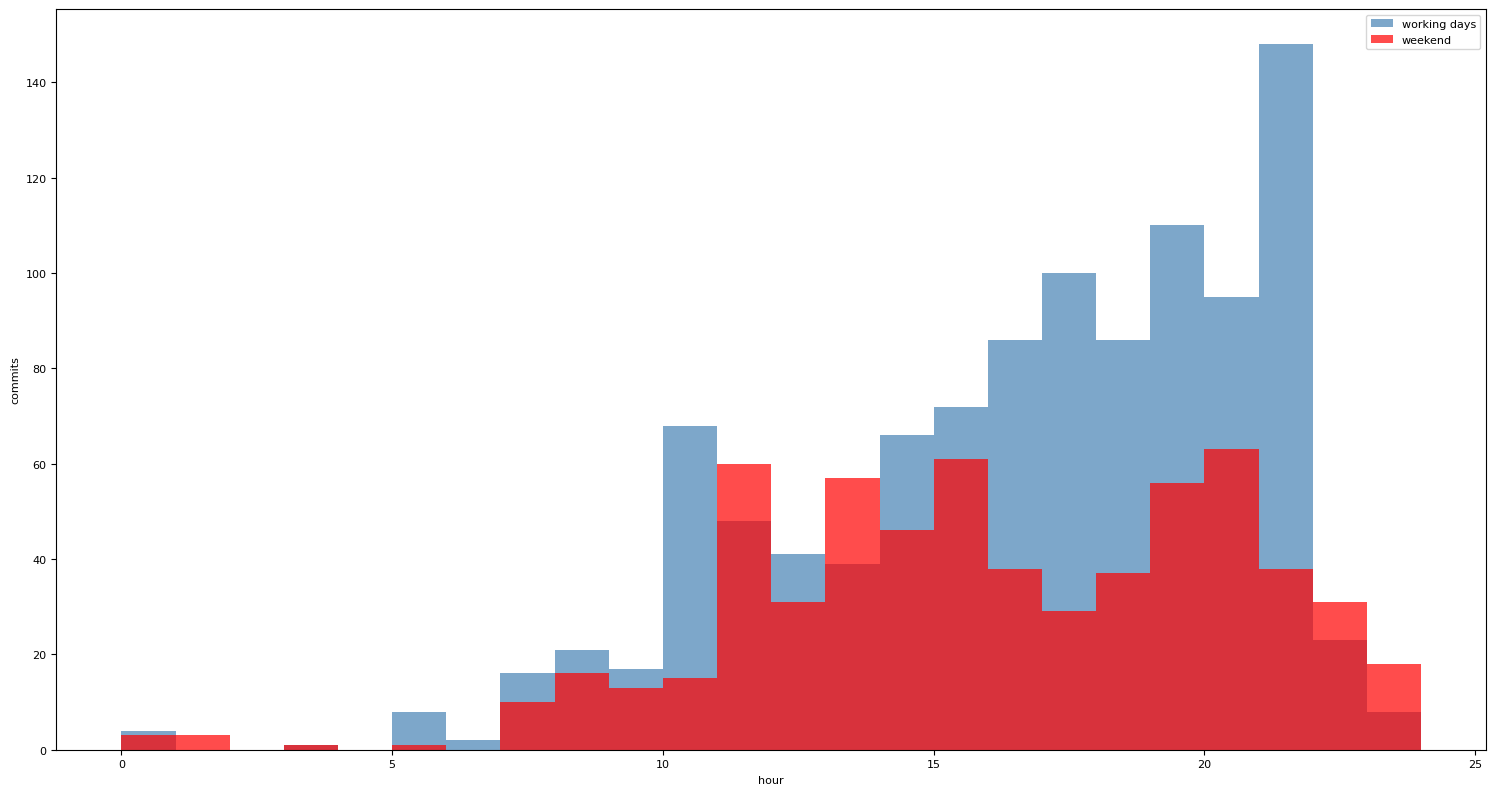

In [4]:
plt.rcParams['font.size'] = 8
fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(working_hours, bins=24, range=(0, 24), alpha=0.7,
        label='working days', color='steelblue')
ax.hist(weekend_hours, bins=24, range=(0, 24), alpha=0.7,
        label='weekend', color='red')

ax.set_xlabel('hour')
ax.set_ylabel('commits')
plt.legend()
plt.tight_layout()
plt.show()

## Answer question

In [5]:
import pandas as pd

working_counts = pd.Series(working_hours).value_counts().sort_index()
weekend_counts = pd.Series(weekend_hours).value_counts().sort_index()

# Find hours where weekend > working_day
combined = pd.DataFrame({'working': working_counts, 'weekend': weekend_counts}).fillna(0)
more_on_weekend = combined[combined['weekend'] > combined['working']]
print('Hours where weekend commits > working day commits:')
print(more_on_weekend)
print(f'\nTop 4 examples: {more_on_weekend.head(4).index.tolist()}')

Hours where weekend commits > working day commits:
    working  weekend
1       0.0      3.0
11     48.0     60.0
13     39.0     57.0
22     23.0     31.0
23      8.0     18.0

Top 4 examples: [1, 11, 13, 22]


Are there hours when the total number of commits was higher on weekends than on working days? The answer is yes. The top four examples: 1, 11, 13, 22.